Bai 1:
Mục tiêu: đưa dữ liệu thực tế về dạng vector/ma trận và đo độ tương đồng giữa các
mẫu.
1. Biến dữ liệu thành ma trận. Tạo ma trận X: với text là (số câu × số từ); với
ảnh là (số ảnh × H · W). In X.shape và giải thích mỗi hàng/cột đại diện cho gì.
2. Phép toán cơ bản. Tính vector trung bình theo cột, trừ trung bình (broadcasting);
in shape trước/sau để minh họa quy tắc broadcasting.
3. Cosine similarity. Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn
hóa theo hàng, keepdims=True), trả về ma trận tương đồng.
4. Truy vấn. Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất
kèm điểm cosine.
5. Nhận xét. Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp
trực giác không?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Khai báo các thư viện cần thiết.

In [2]:
anh=["anh1.jpg","anh2.jpg","anh3.jpg","anh4.jpg","anh5.jpg","anh6.jpg","anh7.jpg","anh8.jpg"]
X = []  
for i in anh:
    M = np.array(Image.open(i).convert("L"), dtype=float) 
    X.append(M.reshape(-1))
X=np.array(X)  
print(X.shape)

(8, 50000)


Tạo một danh sách gồm 8 ảnh nhỏ và một ma trận rỗng X. Sau đó, lần lượt chuyển từng ảnh thành ma trận, rồi biến đổi thành vector một chiều và đưa vào ma trận X. In ra X.shape, kết quả có dạng (8, A), trong đó 8 là số lượng ảnh được đưa vào, còn A là số pixel của mỗi ảnh, được tính bằng chiều dài nhân với chiều rộng của ảnh.

In [3]:
X_mean= X.mean(axis=0, keepdims=True)
print (X_mean.shape)
X_centered= X-X_mean
print(X_centered.shape)

(1, 50000)
(8, 50000)


Broadcasting cho phép NumPy tự động mở rộng `X_mean` để có cùng kích thước với `X` mà không cần tạo thêm một ma trận mới. Điều này giúp chương trình ngắn gọn, tiết kiệm bộ nhớ và tăng hiệu quả tính toán.

In [4]:
def cosinsimilarity(X, Y= None):
 if Y is None:
  Y=X
 Xn= X/ np.linalg.norm(X, axis=1, keepdims=True)
 Yn= Y/ np.linalg.norm(Y, axis=1, keepdims=True)
 return Xn @ Yn.T
S=cosinsimilarity(X)
print(S.shape)

(8, 8)


Tiến hành đo độ tương đồng giữ các vector trong chính ma trận X. Và trả về ma trận tương đồng S.

In [5]:
ketqua=[]
def search(querry_path, topk=3):
  M= np.array(Image.open(querry_path).convert("L").resize((250,200)), dtype= float)
  querry= M.reshape(1,-1)
  scores= cosinsimilarity(querry,X)
  scores=scores.flatten()
  dsx= np.argsort(scores)[::-1]
  for i in dsx[:topk]:
    ketqua.append((int(i), float(scores[i])))
  return (ketqua)
search("test1.jpg", topk=3)
print (ketqua)

[(4, 0.9211263752382881), (1, 0.9159687053728702), (2, 0.8983967065545574)]


Tạo 1 danh sách trống để lưu kết quả từ truy vấn. Về hàm search với hai tham số querry_path và topk. Ta sẽ đưa vào 1 ảnh từ bên ngoài chuyển xám và ma trận hóa nó. Đưa ma trận chứa ảnh về cùng dạng với X. Tiến hành đo độ tương đồng của ảnh đó và X. Kết quả cho ra là 1 ma trận và ta sẽ chuyển nó về dạng mảng 1 chiều. Ta dùng hàm argsort trả về chỉ số index và sắp xếp từ nhỏ đến lớn. [::-1] đảo ngược sắp xếp lại.
Dòng vòng lặp for để đưa 3 chỉ số cao nhất vào tập danh sách trống.

In [6]:
S2=S.copy()
np.fill_diagonal(S2, -1)
max_idx=np.argmax(S2)
max_idx=np.unravel_index(np.argmax(S2), S2.shape)
print(int(max_idx[0]), int(max_idx[1]))
print(S2[max_idx])
S2=S.copy()
np.fill_diagonal(S2, 1)
min_idx=np.argmin(S2)
min_idx=np.unravel_index(np.argmin(S2), S2.shape)
print(int(min_idx[0]), int(min_idx[1]))
print(S2[min_idx])

1 2
0.981390719994195
5 6
0.8844925331738289


Tạo 1 bản sao của S là S2. np.fill_diagonal(S2, -1) đưa đường chéo của ma trận về giá trị -1 để tránh trường hợp nó xem nó giống chính nó nhất. Tìm giá trị cosinsimilarity lớn nhất trong ma trận S2. Nhưng giá trị đưa ra sẽ là vị trí của giá trị cosinsimilarity nên ta cần đưa nó về dạng tọa dộ để có thể xem ảnh nào giống ảnh nào nhất bằng max_idx=np.unravel_index(np.argmax(S2), S2.shape). Cuối cùng là in ra kết quả
Tương tự cho 2 ảnh khác nhau nhất. Chỉ khác là đưa đường chéo lên 1 vì ý trước đưa đường chéo xuống -1.

***************NHẬN XÉT************
Kết quả đưa ra từ chương trình tương đối giống với trực quan quan sát thực tế 

BÀI 2 
1. Biến đổi tuyến tính. Xây ma trận quay R(θ) và ma trận co giãn S; áp lên tọa độ
điểm (hoặc một hình đơn giản) và vẽ trước/sau bằng Matplotlib.
2. Nén ảnh bằng SVD. Phân rã M = UΣV ⊤; giữ lại k giá trị kỳ dị lớn nhất (thử
k = 5, 20, 50), tái tạo và hiển thị ảnh để so sánh.
3. Đánh giá. Tính tỉ lệ nén và sai số tái tạo theo từng k; vẽ đồ thị sai số theo k.
4. Nhận xét. Với k nhỏ tới mức nào thì ảnh vẫn chấp nhận được? Liên hệ với giảm
chiều và nén dữ liệu trong AI.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

Đưa vào các thư viện cần thiết cho chương trình

1. Biến đổi tuyến tính. Xây ma trận quay R(θ) và ma trận co giãn S; áp lên tọa độ
điểm (hoặc một hình đơn giản) và vẽ trước/sau bằng Matplotlib.

(2, 6)


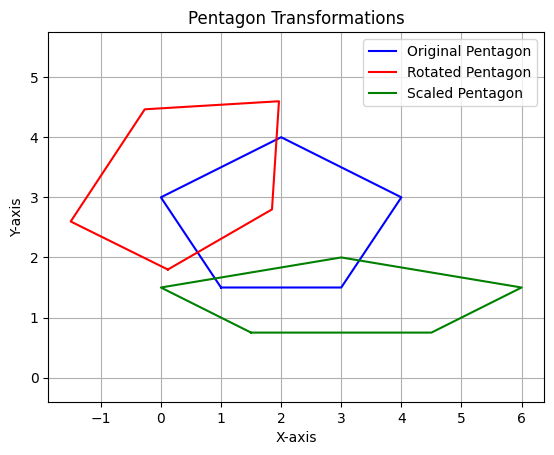

In [8]:
pentagon = np.array([[1, 3, 4, 2, 0, 1], [1.5, 1.5, 3, 4, 3, 1.5]])
theta=np.radians ( 30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]) 
S = np.array([[1.5, 0.0],[0.0, 0.5]])
print(pentagon.shape)
Rotated_pentagon = R @ pentagon
Scaled_pentagon = S @ pentagon
plt.plot(pentagon[0], pentagon[1], label='Original Pentagon', color='blue')
plt.plot(Rotated_pentagon[0], Rotated_pentagon[1], label='Rotated Pentagon', color='red')
plt.plot(Scaled_pentagon[0], Scaled_pentagon[1], label='Scaled Pentagon', color='green')
plt.title('Pentagon Transformations')   
plt.xlabel('X-axis')
plt.ylabel('Y-axis')    
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Vẽ 1 hình ngũ giác( Hoặc hình khác) bất kì. Đầu tiên ta thiết kế 1 ma trận xoay với số đo là 30 (có thể thay đổi). Sau đó ta thiết kế 1 ma trận dãn với 1 số đo ban đầu( có thể thay đổi tùy sử dụng). Ta sẽ kiểm tra kích thước ma trận của biến lưu hình ban đầu. Sau đó ta sẽ dùng dot product để tìm ma trận sau khi xoay và dãn. Tiến hành vẽ 3 hình bằng thư viện matplot với giao diện tùy chọn.

2. Nén ảnh bằng SVD. Phân rã M = UΣV ⊤; giữ lại k giá trị kỳ dị lớn nhất (thử
k = 5, 20, 50), tái tạo và hiển thị ảnh để so sánh.

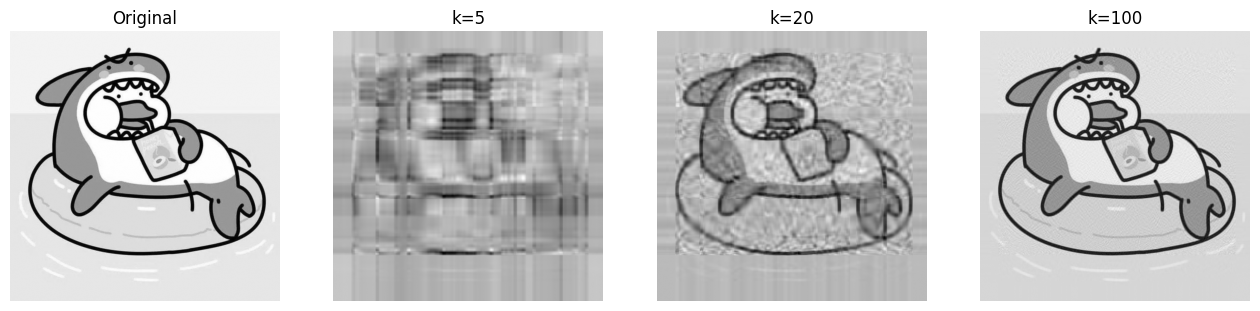

In [9]:
M=np.array(Image.open("bai2.jpg").convert("L"),dtype=float)
U, S, Vt = np. linalg .svd(M, full_matrices = False )
def reconstruct (k):
 return (U[:, :k] * S[:k]) @ Vt [:k, :]
M1 = reconstruct(5)
M2 = reconstruct(20)
M3 = reconstruct(100)
plt.figure(figsize=(16,5))   # tăng chiều rộng
plt.subplot(1,4,1)
plt.imshow(M, cmap='gray')
plt.title('Original')
plt.axis("off")
plt.subplot(1,4,2)
plt.imshow(M1, cmap='gray')
plt.title('k=5')
plt.axis("off")
plt.subplot(1,4,3)
plt.imshow(M2, cmap='gray')
plt.title('k=20')
plt.axis("off")
plt.subplot(1,4,4)
plt.imshow(M3, cmap='gray')
plt.title('k=100')
plt.axis("off")
plt.show()

Ta sẽ đưa 1 ảnh ngoài vào và ma trận hóa nó. Sau đó ta sẽ phân ra nó thành 3 thành phần U, S và Vt với U là chứa các hướng quan trọng theo chiều dọc, S chứa các giá trị kì dị chứa thông tin của ảnh, Vt chứa các hướng quan trọng theo chiều ngang. Hàm econstruct (k) sẽ làm nhiệm vụ ghép các giá trị S, U, Vt này lại được xem là khôi phục ảnh. Ta sẽ tiến hành khôi phục ảnh với 3 giá trị k lần lượt là 5, 20, 100. Hiển thị 3 bức ảnh với plt với giao diện tùy chọn.
*********NHẬN XÉT**********
Với k càng lớn ảnh được khôi phục càng tốt và càng giống với ảnh gốc.

3. Đánh giá. Tính tỉ lệ nén và sai số tái tạo theo từng k; vẽ đồ thị sai số theo k.

[0.21645086367880578, 0.13076678376951864, 0.03014213333624685]
[79.95003123048095, 19.987507807620236, 3.9975015615240475]


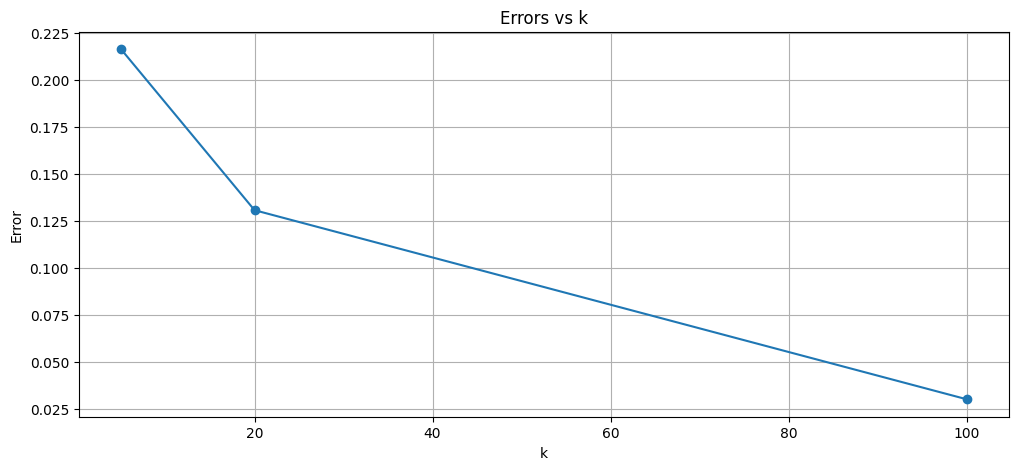

In [10]:
H,W= M.shape
k_values=[5,20,100]
errors=[]
datios=[]
for k in k_values:
 M_k= reconstruct(k)
 error=float(np.linalg.norm((M - M_k))/np.linalg.norm(M))
 errors.append(error)
 datio=(H*W)/(H*k+k+W*k)
 datios.append(datio)
print(errors)
print(datios)
plt.figure(figsize=(12,5))
plt.plot(k_values,errors, "o-")
plt.xlabel("k")
plt.ylabel("Error")
plt.title ("Errors vs k")
plt.grid(True)
plt.show()


Ta sẽ tiến hành lấy dữ liệu đặc trưng từ 2 ảnh và tính ra các giá trị sai số cũng như tỉ lệ nén với từng k. Từ đó vẽ đồ thị.

4. Nhận xét. Với k nhỏ tới mức nào thì ảnh vẫn chấp nhận được? Liên hệ với giảm
chiều và nén dữ liệu trong AI.

***************Nhận xét************** 
Dựa vào đồ thị ta thấy sai số ảnh của ảnh ban đầu với k nhỏ là rất lớn và đồ thị có hướng dốc xuống cao. Đến giá trị 20 thì sai só được giảm đáng kể và hình ảnh bắt đầu thể hiện được những nét đặc trưng của ảnh gốc. Ngoài ra, lúc này đồ thị cũng có dạng bị gãy khúc với các giá trị lớn hơn 20 đồ thị có độ dốc ít hơn ban đầu.
Để quá trình huấn luyện được tối ưu ta phải cân bằng được hai yếu tố độ nén và sai số của thuật toán. Nếu ta nén kích thước hình ảnh về quá nhỏ sẽ khiến mất đi những thông tin đặc trưng của bức ảnh.